In [60]:
from random import random, sample
from icecream import ic
import numpy as np
from typing import Sequence
from tqdm.auto import tqdm
from itertools import accumulate
from matplotlib import pyplot as plt
N = 2000

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [61]:
OBJECTS = {n for n in range(N)}
SETS = tuple(frozenset(sample(range(N), k=s+1)) for s in range(N))
COSTS = tuple(10*random()+(s+random())**2 for s in range(N))


In [62]:
SETS

(frozenset({81}),
 frozenset({305, 1032}),
 frozenset({598, 1131, 1423}),
 frozenset({348, 915, 1191, 1830}),
 frozenset({261, 877, 1444, 1889, 1932}),
 frozenset({401, 785, 884, 1007, 1070, 1073}),
 frozenset({438, 782, 800, 1215, 1287, 1301, 1840}),
 frozenset({66, 389, 618, 678, 715, 1041, 1708, 1968}),
 frozenset({126, 224, 236, 306, 700, 1197, 1619, 1672, 1857}),
 frozenset({22, 271, 379, 502, 669, 805, 1503, 1582, 1745, 1881}),
 frozenset({37, 106, 195, 273, 825, 1249, 1365, 1551, 1730, 1756, 1809}),
 frozenset({3, 113, 169, 214, 238, 295, 415, 805, 916, 1602, 1691, 1764}),
 frozenset({86,
            444,
            468,
            484,
            765,
            797,
            1331,
            1370,
            1392,
            1479,
            1497,
            1531,
            1759}),
 frozenset({164,
            502,
            646,
            673,
            1007,
            1158,
            1327,
            1375,
            1550,
            1603,
        

In [63]:
COSTS

(2.954431098651749,
 6.614880324471063,
 8.050179754993549,
 17.693051024018093,
 22.66880768627686,
 32.42106178161111,
 49.52926268918035,
 60.970172135157824,
 85.25701920331429,
 108.31361546205036,
 119.52647222926376,
 137.49023926977685,
 173.37119057274742,
 190.76940058319005,
 208.4320396312337,
 256.953786246925,
 280.2943046841423,
 324.268123124377,
 339.5202282014625,
 377.6103891585538,
 419.76660250142584,
 483.32274547048337,
 501.49791781118364,
 536.0043675018176,
 588.029304910948,
 644.7065611351356,
 714.8818263375662,
 758.4459606182686,
 828.1538520871469,
 887.8380625087117,
 912.442042986695,
 1020.4467460341172,
 1033.9244368924567,
 1128.9342464224524,
 1210.4536741780942,
 1246.5737066919958,
 1365.6205129421014,
 1381.4906145245898,
 1470.234969632756,
 1532.2859265837365,
 1679.6728702388784,
 1765.336172801179,
 1774.3924800917675,
 1921.3833580276269,
 1996.2231975897637,
 2064.522560821551,
 2187.9353925280343,
 2298.2851107408974,
 2339.2578186945293,

In [64]:
def fitness_aob(solution: Sequence[bool]) -> float:
    # Why returning weight? -> trying to go up - trying to maximize it
    weight = sum(COSTS[n] for n in range(N) if solution[n])
    check = frozenset().union(*(SETS[n] for n in range(N) if solution[n]))
    #assert check == frozenset(range(N))

    if check != frozenset(range(N)):
        return float("-inf")
    return -weight

solution = tuple(sample([True, False], k=N, counts=(N, N)))

fitness_aob(solution)

-1337753440.900138

Selected sets: []
Covered objects: 0
Adding set: 1227
Selected sets: [1227]
Covered objects: 1228
Adding set: 911
Selected sets: [ 911 1227]
Covered objects: 1589
Adding set: 217
Selected sets: [ 217  911 1227]
Covered objects: 1657
Adding set: 473
Selected sets: [ 217  473  911 1227]
Covered objects: 1743
Adding set: 431
Selected sets: [ 217  431  473  911 1227]
Covered objects: 1803
Adding set: 340
Selected sets: [ 217  340  431  473  911 1227]
Covered objects: 1839
Adding set: 550
Selected sets: [ 217  340  431  473  550  911 1227]
Covered objects: 1886
Adding set: 1635
Selected sets: [ 217  340  431  473  550  911 1227 1635]
Covered objects: 1983
Adding set: 1312
Selected sets: [ 217  340  431  473  550  911 1227 1312 1635]
Covered objects: 1992
Adding set: 1277
Selected sets: [ 217  340  431  473  550  911 1227 1277 1312 1635]
Covered objects: 1994
Adding set: 1757
Selected sets: [ 217  340  431  473  550  911 1227 1277 1312 1635 1757]
Covered objects: 2000
All objects covered
Sta

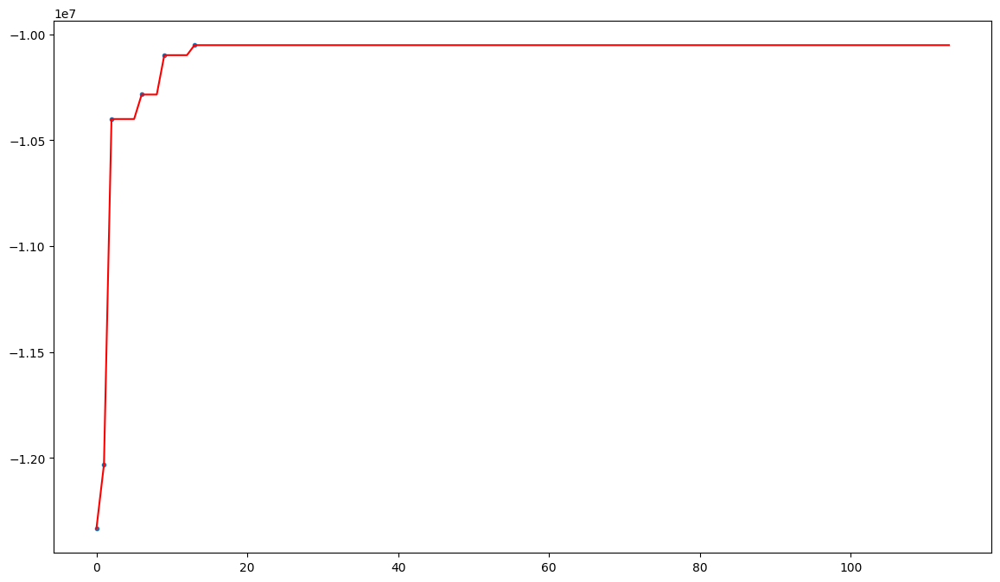

In [73]:
# Certain number of calls to fitness / number of steps or after some time (1 minute)
solution = np.full(N, False)
history = [fitness_aob(solution)]
max_no_improvement = 100
no_improvement = 0

while True: # do it til we have all sets covered
    selected_sets = [SETS[i] for i in range(N) if solution[i]]

    if selected_sets:
        covered = frozenset().union(*selected_sets) # if we selected sets, combine them
    else:
        covered = frozenset() # if none, empty set

    print("Selected sets:", np.where(solution)[0])
    print("Covered objects:", len(covered))

    if covered == OBJECTS: # if everything is selected
        print("All objects covered")
        print("Starting fitness:", fitness_aob(solution))
        break

    index = np.random.randint(0, N)

    if not solution[index]:
        print("Adding set:", index)
        solution[index] = True # if we haven't selected a certain set, add it


history = [fitness_aob(solution)]
    
for steps in range(len(OBJECTS)):

    new_solution = solution.copy()

    #index = np.random.randint(0, N)

    selected_indices = np.where(solution)[0]
    index = np.random.choice(selected_indices)

    print("\nStep:", steps)
    print("Chosen index:", index)

    if new_solution[index]:
        print("Removing set:", index)
        new_solution[index] = False # if we have a certain set covered, remove it

        print("Current fitness:", fitness_aob(solution))
    print("New fitness:", fitness_aob(new_solution))

    history.append(fitness_aob(new_solution))

    if fitness_aob(new_solution) > fitness_aob(solution):
        print("Improvement found")
        solution = new_solution
        no_improvement = 0
    else:
        print("No improvement")
        no_improvement += 1

    if no_improvement >= max_no_improvement:
        break




plt.figure(figsize=(14, 8))
plt.plot(
    range(len(history)),
    list(accumulate(history, max)),
    color="red",
)
_ = plt.scatter(range(len(history)), history, marker=".")